# Ranking de Metabolitos más Importantes — GC-MS

**Objetivo:** Identificar los metabolitos más sensibles al cambio experimental, partiendo de los resultados ya calculados en el análisis Analisis-Metabol-mico-Estad-stico-con-Python. Para posteriormente indicar las características de cada uno según el proyecto de base de datos del proyecto Mental-Health-Biomarkers-Database

## Ánálisis realizado

"Metabolito importante" = **más sensible al cambio experimental**, no el más abundante ni el más común.

### Criterios de priorización (de mayor a menor peso):
| Criterio | Descripción | Peso por defecto |
|---|---|---|
| Varianza entre condiciones | Cuánto cambia el metabolito entre clusters | 0.40 |
| \|log2FC\| | Magnitud del cambio entre condiciones | 0.30 |
| SHAP importance | Contribución al modelo discriminativo | 0.20 |
| p_adjusted (inverso) | Significación estadística | 0.10 |

### Tratamiento de duplicados:
- Un compuesto con el mismo nombre en distintos RT → se mantiene el **representante con mayor variabilidad**.
- Los demás se guardan como duplicados descartados con trazabilidad.
- Derivados → se mantienen separados, con un **flag** de posible derivado.

### Archivos de salida:
- `master_table_curated.csv` — tabla maestra depurada (un representante por compuesto)
- `top_metabolites_ranked.csv` — ranking final por score combinado
- `discarded_duplicates.csv` — picos descartados con motivo

## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.max_rows', 50)

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Configuración

Ajusta aquí las rutas y parámetros antes de ejecutar.

In [2]:
# ============================================================
# CONFIGURACIÓN — modifica según tus rutas y preferencias
# ============================================================

DATA_PROC = Path('../data/processed csv')
DATA_OUT  = Path('../data/processed csv')

# --- Archivo principal (tabla integrada con todas las métricas) ---
FILE_INTEGRATED = DATA_PROC / '08_integrated_ranking.csv'

# --- Archivo con abundancias crudas por experimento ---
FILE_PEAKS = DATA_PROC / 'peaks_clean.csv'

# --- Archivo con asignación de experimentos a condiciones (clusters) ---
FILE_CLUSTERS = DATA_PROC / 'experiment_clusters_no_outlier.csv'

# --- Base de datos de biomarkers de salud mental ---
FILE_BIOMARKERS = Path('../data/raw/MH_Biomarkers_Salud_Mental_CURADO.xlsx')

# --- Mapeo manual de columnas ---
COL_MAP = {
    'metabolite' : 'metabolite',
    'log2fc'     : 'abs_log2fc',
    'shap'       : 'shap_mean_abs',
    'p_adjusted' : 'p_adjusted',
    'variance'   : None,
}

# --- Pesos del score combinado (deben sumar 1.0) ---
WEIGHTS = {
    'variance'   : 0.40,
    'log2fc'     : 0.30,
    'shap'       : 0.20,
    'p_adjusted' : 0.10,
}

# --- Percentil mínimo para conservar derivados en el ranking final ---
# Derivados con score < este percentil (sobre todos los metabolitos) se descartan
DERIVATIVE_MIN_PERCENTILE = 0.40

print('Configuración cargada.')
print(f'  Pesos: {WEIGHTS}')
print(f'  Derivados: se conservan si score >= percentil {DERIVATIVE_MIN_PERCENTILE:.0%}')


Configuración cargada.
  Pesos: {'variance': 0.4, 'log2fc': 0.3, 'shap': 0.2, 'p_adjusted': 0.1}
  Derivados: se conservan si score >= percentil 40%


## 2. Funciones auxiliares

In [3]:
# ============================================================
# FUNCIÓN: estandarizar nombres de metabolitos
# ============================================================

def standardize_name(name: str) -> str:
    """
    Normaliza el nombre de un metabolito para comparación:
    - Convierte a minúsculas
    - Elimina espacios extra y caracteres de control
    - Colapsa espacios múltiples
    - Quita puntuación irrelevante al final
    """
    if pd.isna(name):
        return ''
    s = str(name).strip().lower()
    s = re.sub(r'[\x00-\x1f\x7f]', '', s)   # caracteres de control
    s = re.sub(r'\s+', ' ', s)               # colapsar espacios
    s = s.rstrip('.,')
    return s


def flag_possible_derivative(name: str, all_names: list) -> bool:
    """
    Devuelve True si el nombre parece ser un derivado de otro compuesto
    presente en la lista (p. ej. 'acetone' → 'acetone, 2-methyl-').
    NOTA: solo marca con flag; no fusiona automáticamente.
    """
    if not name:
        return False
    for other in all_names:
        if other == name:
            continue
        # Es derivado si empieza por el mismo token raíz y añade sufijo
        if other.startswith(name + ',') or other.startswith(name + ' '):
            return True
        if name.startswith(other + ',') or name.startswith(other + ' '):
            return True
    return False


print('Funciones de estandarización definidas.')

Funciones de estandarización definidas.


In [4]:
# ============================================================
# FUNCIÓN: detectar columnas disponibles
# ============================================================

def detect_columns(df: pd.DataFrame, col_map: dict) -> dict:
    """
    Busca en el DataFrame las columnas definidas en col_map.
    Si col_map[key] es None, intenta heurísticas de nombres comunes.
    Devuelve un diccionario {clave_interna: nombre_real_en_df} o None si no existe.
    """
    cols_lower = {c.lower(): c for c in df.columns}

    # Candidatos alternativos por clave semántica
    FALLBACKS = {
        'metabolite' : ['compound_name', 'compound name', 'name', 'metabolite', 'peak_name', 'compuesto'],
        'log2fc'     : ['abs_log2fc', 'log2fc', '|log2fc|', 'log2_fc', 'fold_change', 'fc'],
        'shap'       : ['shap_mean_abs', 'shap', 'mean_shap', 'importance', 'shap_importance'],
        'p_adjusted' : ['p_adjusted', 'padj', 'fdr', 'q_value', 'q_val', 'p_adj'],
        'variance'   : ['variance', 'var_between', 'between_var', 'var_conditions'],
        'rt'         : ['est. retention time (min)', 'rt', 'retention_time', 'rt_min'],
    }

    resolved = {}
    for key, user_col in col_map.items():
        if user_col is not None and user_col in df.columns:
            resolved[key] = user_col
        else:
            # Búsqueda por fallbacks
            found = None
            for candidate in FALLBACKS.get(key, []):
                if candidate in cols_lower:
                    found = cols_lower[candidate]
                    break
            resolved[key] = found

    return resolved


print('Función de detección de columnas definida.')

Función de detección de columnas definida.


In [5]:
# ============================================================
# FUNCIÓN: calcular varianza entre condiciones desde datos crudos
# ============================================================

def compute_between_condition_variance(
    peaks_df: pd.DataFrame,
    clusters_df: pd.DataFrame,
    name_col: str = 'Compound Name'
) -> pd.DataFrame:
    """
    Calcula la varianza entre condiciones para cada pico en peaks_df.

    Parámetros
    ----------
    peaks_df   : DataFrame con columnas Exp_X.CDF por experimento
    clusters_df: DataFrame con columnas 'experiment' y 'cluster'
    name_col   : columna con el nombre del compuesto en peaks_df

    Devuelve
    --------
    DataFrame con columnas: [name_col, 'rt', 'variance_between_conditions']
    """
    # Columnas de experimentos presentes en peaks_df
    exp_cols = [c for c in peaks_df.columns if c.startswith('Exp_') and c.endswith('.CDF')]

    # Mapa experimento → cluster (solo los experimentos que aparecen en clusters_df)
    exp_to_cluster = dict(zip(
        clusters_df['experiment'] + '.CDF',
        clusters_df['cluster']
    ))

    # Filtrar solo columnas que tienen asignación de cluster
    exp_cols_in_clusters = [c for c in exp_cols if c in exp_to_cluster]

    cluster_ids = sorted(clusters_df['cluster'].unique())

    results = []
    for _, row in peaks_df.iterrows():
        compound = row[name_col]
        rt = row.get('Est. Retention Time (min)', np.nan)

        # Calcular media de abundancia por cluster
        cluster_means = []
        for cid in cluster_ids:
            cols_cid = [c for c in exp_cols_in_clusters if exp_to_cluster[c] == cid]
            if cols_cid:
                vals = pd.to_numeric(row[cols_cid], errors='coerce')
                cluster_means.append(np.nanmean(vals))
            else:
                cluster_means.append(np.nan)

        # Varianza de las medias entre clusters (cuánto cambia el metabolito entre condiciones)
        var_between = np.nanvar(cluster_means, ddof=0) if sum(~np.isnan(cluster_means)) > 1 else 0.0

        results.append({
            name_col                      : compound,
            'rt'                          : rt,
            'variance_between_conditions' : var_between,
        })

    return pd.DataFrame(results)


print('Función de varianza entre condiciones definida.')

Función de varianza entre condiciones definida.


In [6]:
# ============================================================
# FUNCIÓN: min-max normalización (robusto a NaN)
# ============================================================

def minmax_normalize(series: pd.Series, invert: bool = False) -> pd.Series:
    """
    Normaliza una Serie entre 0 y 1.
    Si invert=True, invierte (para p_adjusted donde menor = mejor).
    Los NaN se mantienen como NaN.
    """
    s = series.copy().astype(float)
    mn, mx = s.min(), s.max()
    if mx == mn:
        return pd.Series(np.where(s.isna(), np.nan, 0.5), index=s.index)
    norm = (s - mn) / (mx - mn)
    if invert:
        norm = 1 - norm
    return norm


def compute_combined_score(
    df: pd.DataFrame,
    cols: dict,
    weights: dict
) -> pd.Series:
    """
    Calcula un score combinado ponderado.

    cols    : {'variance': col_name, 'log2fc': col_name, 'shap': col_name, 'p_adjusted': col_name}
              Si col_name es None, ese criterio se omite y se redistribuyen los pesos.
    weights : {'variance': 0.4, 'log2fc': 0.3, 'shap': 0.2, 'p_adjusted': 0.1}
    """
    active = {k: v for k, v in cols.items() if v is not None and v in df.columns}

    if not active:
        raise ValueError('No se encontró ninguna columna válida para el score combinado.')

    # Redistribuir pesos solo entre los criterios disponibles
    active_weights = {k: weights.get(k, 0) for k in active}
    total_w = sum(active_weights.values())
    if total_w == 0:
        total_w = 1
    active_weights = {k: v / total_w for k, v in active_weights.items()}

    score = pd.Series(0.0, index=df.index)
    norm_components = {}

    for key, col in active.items():
        if key == 'p_adjusted':
            norm = minmax_normalize(df[col], invert=True)  # menor p = mejor
        else:
            norm = minmax_normalize(df[col], invert=False)  # mayor = mejor

        # Rellenar NaN con la mediana de la columna normalizada (para no penalizar ausencia)
        median_fill = norm.median()
        norm = norm.fillna(median_fill if not np.isnan(median_fill) else 0.0)
        norm_components[key] = norm

        score += norm * active_weights[key]

    print(f'  Criterios activos y pesos redistribuidos:')
    for k, w in active_weights.items():
        print(f'    {k:15s}: {w:.3f}  (columna: {active[k]})')

    return score


print('Funciones de scoring definidas.')

Funciones de scoring definidas.


In [7]:
# ============================================================
# FUNCIÓN: deduplicar por nombre estandarizado
# ============================================================

def deduplicate_metabolites(
    df: pd.DataFrame,
    name_col: str,
    priority_cols: list   # lista de columnas en orden de prioridad (mayor = mejor)
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Agrupa por nombre estandarizado y elige un representante único por compuesto.

    Criterio de selección del representante:
    1. Mayor valor en priority_cols[0]  (varianza entre condiciones)
    2. Mayor valor en priority_cols[1]  (|log2FC|)  — desempate
    3. Mayor valor en priority_cols[2]  (SHAP)      — segundo desempate

    Devuelve
    --------
    (df_curated, df_discarded)
    """
    # Estandarizar nombre para agrupación
    df = df.copy()
    df['_name_std'] = df[name_col].apply(standardize_name)

    # Ordenar por criterios de prioridad (desc) para que el primero sea el mejor
    sort_cols = [c for c in priority_cols if c in df.columns]
    if sort_cols:
        df = df.sort_values(sort_cols, ascending=False, na_position='last')

    # Separar representantes y duplicados
    curated_rows  = []
    discarded_rows = []

    for std_name, group in df.groupby('_name_std', sort=False):
        group = group.reset_index(drop=True)
        # El primer elemento (ya ordenado) es el representante
        curated_rows.append(group.iloc[0])

        if len(group) > 1:
            for i, row in group.iloc[1:].iterrows():
                row_copy = row.copy()
                row_copy['_discard_reason'] = 'Duplicado de: ' + str(group.iloc[0][name_col])
                row_copy['_representative'] = str(group.iloc[0][name_col])
                discarded_rows.append(row_copy)

    df_curated   = pd.DataFrame(curated_rows).reset_index(drop=True)
    df_discarded = pd.DataFrame(discarded_rows).reset_index(drop=True) if discarded_rows else pd.DataFrame()

    # Quitar columna auxiliar
    df_curated   = df_curated.drop(columns=['_name_std'], errors='ignore')
    if not df_discarded.empty:
        df_discarded = df_discarded.drop(columns=['_name_std'], errors='ignore')

    return df_curated, df_discarded


print('Función de deduplicación definida.')

Función de deduplicación definida.


## 3. Carga de datos

In [8]:
# ============================================================
# CARGAR TABLA INTEGRADA PRINCIPAL
# ============================================================

print('Cargando tabla integrada...')
df_main = pd.read_csv(FILE_INTEGRATED, encoding='utf-8')

print(f'  Shape: {df_main.shape}')
print(f'  Columnas disponibles:')
for col in df_main.columns:
    n_null = df_main[col].isna().sum()
    print(f'    {col:35s}  ({n_null} NaN)')
print()
print(f'  Metabolitos únicos: {df_main["metabolite"].nunique()}')
print(f'  Filas totales:      {len(df_main)}')

Cargando tabla integrada...
  Shape: (1055, 13)
  Columnas disponibles:
    metabolite                           (0 NaN)
    shap_mean_abs                        (0 NaN)
    shap_rank                            (0 NaN)
    log2fc                               (506 NaN)
    effect_size                          (0 NaN)
    p_value                              (0 NaN)
    abs_log2fc                           (506 NaN)
    fc_rank                              (0 NaN)
    p_adjusted                           (0 NaN)
    neg_log10_p                          (0 NaN)
    pval_rank                            (0 NaN)
    combined_score                       (0 NaN)
    final_rank                           (0 NaN)

  Metabolitos únicos: 143
  Filas totales:      1055


In [9]:
# ============================================================
# CARGAR DATOS CRUDOS Y CLUSTERS PARA CALCULAR VARIANZA
# ============================================================

peaks_available    = FILE_PEAKS.exists()
clusters_available = FILE_CLUSTERS.exists()

if peaks_available and clusters_available:
    print('Cargando datos crudos de picos...')
    df_peaks    = pd.read_csv(FILE_PEAKS)
    df_clusters = pd.read_csv(FILE_CLUSTERS)
    print(f'  peaks_clean shape:    {df_peaks.shape}')
    print(f'  clusters shape:       {df_clusters.shape}')
    print()
    print('Condiciones experimentales (clusters):')
    print(df_clusters.groupby('cluster')['experiment'].apply(list).to_string())
else:
    df_peaks    = None
    df_clusters = None
    print('AVISO: No se encontraron datos crudos. La varianza entre condiciones no se calculará.')

Cargando datos crudos de picos...
  peaks_clean shape:    (372, 32)
  clusters shape:       (15, 3)

Condiciones experimentales (clusters):
cluster
0                                   [Exp_1, Exp_2, Exp_3, Exp_4]
1    [Exp_5, Exp_6, Exp_7, Exp_10, Exp_12, Exp_13, Exp_14, Ex...
2                                                        [Exp_8]


## 4. Detección automática de columnas

In [10]:
# ============================================================
# DETECTAR COLUMNAS EN EL DATAFRAME PRINCIPAL
# ============================================================

resolved_cols = detect_columns(df_main, COL_MAP)

print('Columnas detectadas:')
for k, v in resolved_cols.items():
    status = '✓' if v is not None else '✗ (no disponible — se omitirá)'
    print(f'  {k:15s}: {v}  {status}')

Columnas detectadas:
  metabolite     : metabolite  ✓
  log2fc         : abs_log2fc  ✓
  shap           : shap_mean_abs  ✓
  p_adjusted     : p_adjusted  ✓
  variance       : None  ✗ (no disponible — se omitirá)


## 5. Cálculo de varianza entre condiciones

In [11]:
# ============================================================
# CALCULAR VARIANZA ENTRE CONDICIONES (desde datos crudos)
# ============================================================

# Comprobamos si la varianza ya está en la tabla principal
variance_col_main = resolved_cols.get('variance')

if variance_col_main is not None:
    print(f'Varianza entre condiciones ya disponible en columna: {variance_col_main}')
    df_variance = None

elif df_peaks is not None and df_clusters is not None:
    print('Calculando varianza entre condiciones desde datos crudos...')
    df_variance = compute_between_condition_variance(
        peaks_df=df_peaks,
        clusters_df=df_clusters,
        name_col='Compound Name'
    )

    # Log2 del área es más estable → usamos log2(varianza+1) para normalización posterior
    df_variance['variance_between_conditions_log'] = np.log2(
        df_variance['variance_between_conditions'] + 1
    )

    print(f'  Picos analizados:  {len(df_variance)}')
    print(f'  Rango varianza:    {df_variance["variance_between_conditions"].min():.2e} — '
          f'{df_variance["variance_between_conditions"].max():.2e}')
    print()
    print('Top 10 picos por varianza entre condiciones:')
    top_var = df_variance.nlargest(10, 'variance_between_conditions')[['Compound Name', 'rt', 'variance_between_conditions']]
    display(top_var)

else:
    df_variance = None
    print('AVISO: No se puede calcular varianza. El score se basará en log2FC, SHAP y p_adjusted.')

Calculando varianza entre condiciones desde datos crudos...
  Picos analizados:  372
  Rango varianza:    1.88e+02 — 4.13e+20

Top 10 picos por varianza entre condiciones:


,Compound Name,rt,variance_between_conditions
369,"Indole, 3-[3-(4-morpholinyl)prop-1-enyl]-",59.325183,4.132779e+20
176,p-Cresol,18.723333,1.214966e+14
227,Indole,28.943767,4.040896e+12
262,"Indole, 3-methyl-",33.006117,2.746832e+12
193,"Phenol, 4-ethyl-",22.857433,2.434544e+11
126,Benzaldehyde,12.834367,5.178749e+10
171,Benzeneacetaldehyde,16.684983,4.095681e+10
174,Benzeneacetaldehyde,16.925417,2.818993e+10
141,Phenol,13.677700,2.685668e+10
175,Benzeneacetaldehyde,17.076150,2.405760e+10


## 6. Construcción de la tabla maestra

In [12]:
# ============================================================
# CONSTRUIR TABLA DE TRABAJO UNIFICADA
# ============================================================

# Partimos de la tabla integrada
df_work = df_main.copy()

# Columna de nombre (alias estándar)
met_col = resolved_cols['metabolite']
if met_col is None:
    raise ValueError('No se encontró columna con nombre de metabolito.')

# ── Integrar varianza calculada desde datos crudos ─────────────────────────
if df_variance is not None:
    # Crear columna de nombre estandarizado para el join
    df_variance['_name_std'] = df_variance['Compound Name'].apply(standardize_name)
    df_work['_name_std']     = df_work[met_col].apply(standardize_name)

    # Merge: asignamos la varianza máxima por nombre estandarizado (máx entre picos duplicados)
    var_max = (
        df_variance.groupby('_name_std')[['variance_between_conditions', 'variance_between_conditions_log', 'rt']]
        .max()
        .reset_index()
    )

    df_work = df_work.merge(var_max, on='_name_std', how='left')
    df_work = df_work.drop(columns=['_name_std'], errors='ignore')

    # Actualizar el mapa de columnas con la nueva columna
    resolved_cols['variance'] = 'variance_between_conditions_log'
    print(f'Varianza entre condiciones añadida: {df_work["variance_between_conditions_log"].notna().sum()} filas con valor.')

elif variance_col_main is not None:
    resolved_cols['variance'] = variance_col_main
    print(f'Usando varianza existente: {variance_col_main}')

else:
    resolved_cols['variance'] = None
    print('Varianza no disponible — se omitirá del score.')

# ── Añadir RT desde peaks si no está ya en la tabla principal ─────────────
if 'rt' not in df_work.columns and df_variance is not None:
    # rt ya se incorporó en el merge anterior
    pass
elif 'rt' not in df_work.columns and df_peaks is not None:
    rt_map = df_peaks.groupby(df_peaks['Compound Name'].apply(standardize_name))['Est. Retention Time (min)'].first()
    df_work['_name_std'] = df_work[met_col].apply(standardize_name)
    df_work['rt'] = df_work['_name_std'].map(rt_map)
    df_work = df_work.drop(columns=['_name_std'], errors='ignore')

print(f'\nTabla de trabajo: {df_work.shape}')
df_work.head(10)

Varianza entre condiciones añadida: 1055 filas con valor.

Tabla de trabajo: (1055, 16)


,metabolite,shap_mean_abs,shap_rank,log2fc,effect_size,p_value,abs_log2fc,fc_rank,p_adjusted,neg_log10_p,pval_rank,combined_score,final_rank,variance_between_conditions,variance_between_conditions_log,rt
0,Phenol,0.006287,2.0,10.627467,-16.037986,0.117647,10.627467,4.0,0.166617,0.778281,60.5,22.166667,1,2.685668e+10,34.644562,13.727950
1,cis-Calamenene,0.004968,7.0,10.085172,-8.536268,0.117647,10.085172,5.0,0.166617,0.778281,60.5,24.166667,2,2.656985e+07,24.663287,38.471600
2,cis-Calamenene,0.004968,7.0,9.538843,-9.023157,0.117647,9.538843,6.0,0.166617,0.778281,60.5,24.500000,3,2.656985e+07,24.663287,38.471600
3,γ-Muurolene,0.004638,9.0,7.545405,-8.549666,0.117647,7.545405,17.0,0.166617,0.778281,60.5,28.833333,4,6.091856e+06,22.538451,36.580400
4,Methyl salicylate,0.004319,13.0,6.979729,-8.691161,0.117647,6.979729,21.0,0.166617,0.778281,60.5,31.500000,5,1.283236e+07,23.613284,24.149350
5,α-Cubebene,0.004000,18.0,7.531006,-4.644634,0.117647,7.531006,18.0,0.166617,0.778281,60.5,32.166667,6,8.416283e+08,29.648608,35.442800
6,Dimethyl trisulfide,0.003319,32.0,8.718576,-11.919842,0.117647,8.718576,7.0,0.166617,0.778281,60.5,33.166667,7,1.058798e+10,33.301708,13.085583
7,Dimethyl trisulfide,0.003319,32.0,8.718576,-11.919842,0.117647,8.718576,7.0,0.166617,0.778281,60.5,33.166667,8,1.058798e+10,33.301708,13.085583
8,"5,9-Undecadien-2-one, 6,10-dimethyl-",0.003968,20.0,7.010074,-10.618950,0.117647,7.010074,20.0,0.166617,0.778281,60.5,33.500000,9,1.251259e+07,23.576878,35.550450
9,Humulene,0.006803,1.0,6.219568,-8.644076,0.117647,6.219568,41.0,0.166617,0.778281,60.5,34.166667,10,2.132460e+08,27.667943,35.733467


## 7. Estandarización de nombres y flag de derivados

In [13]:
# ============================================================
# ESTANDARIZAR NOMBRES Y MARCAR POSIBLES DERIVADOS
# ============================================================

df_work['name_std'] = df_work[met_col].apply(standardize_name)

# Lista de nombres únicos estandarizados (para detectar derivados)
unique_names_std = df_work['name_std'].unique().tolist()

# Marcar compuestos que podrían ser derivados de otro presente en el dataset
df_work['flag_possible_derivative'] = df_work['name_std'].apply(
    lambda n: flag_possible_derivative(n, unique_names_std)
)

n_derivatives = df_work['flag_possible_derivative'].sum()
print(f'Compuestos con flag de posible derivado: {n_derivatives} filas')
if n_derivatives > 0:
    print('  (Flag informativo — NO se fusionan automáticamente)')
    sample = df_work[df_work['flag_possible_derivative']][[met_col]].drop_duplicates().head(10)
    display(sample)

Compuestos con flag de posible derivado: 111 filas
  (Flag informativo — NO se fusionan automáticamente)


,metabolite
0,Phenol
8,"5,9-Undecadien-2-one, 6,10-dimethyl-"
17,"Benzeneacetaldehyde, α-ethylidene-"
19,"Indole, 3-methyl-"
25,"Tetradecane, 3-methyl-"
53,Caryophyllene oxide
79,Tetradecane
99,Dodecane
104,Caryophyllene
115,Indole


## 8. Score combinado (pre-deduplicación)

In [14]:
# ============================================================
# CALCULAR SCORE COMBINADO ANTES DE DEDUPLICAR
# (necesario para elegir el mejor representante por compuesto)
# ============================================================

# Mapa de columnas para el score (solo las que existen en el df)
score_cols = {
    'variance'   : resolved_cols.get('variance'),
    'log2fc'     : resolved_cols.get('log2fc'),
    'shap'       : resolved_cols.get('shap'),
    'p_adjusted' : resolved_cols.get('p_adjusted'),
}

print('Calculando score combinado...')
df_work['combined_score_new'] = compute_combined_score(df_work, score_cols, WEIGHTS)

print(f'\nScore calculado. Rango: {df_work["combined_score_new"].min():.4f} — {df_work["combined_score_new"].max():.4f}')
print(f'Media: {df_work["combined_score_new"].mean():.4f}')

Calculando score combinado...
  Criterios activos y pesos redistribuidos:
    variance       : 0.400  (columna: variance_between_conditions_log)
    log2fc         : 0.300  (columna: abs_log2fc)
    shap           : 0.200  (columna: shap_mean_abs)
    p_adjusted     : 0.100  (columna: p_adjusted)

Score calculado. Rango: 0.0987 — 0.7338
Media: 0.4005


## 9. Deduplicación: un representante por compuesto

In [15]:
# ============================================================
# DEDUPLICAR POR NOMBRE ESTANDARIZADO
# Criterio: mayor varianza → mayor |log2FC| → mayor SHAP
# ============================================================

# Columnas de prioridad para elegir representante
priority_order = [
    c for c in [
        resolved_cols.get('variance'),
        resolved_cols.get('log2fc'),
        resolved_cols.get('shap'),
    ]
    if c is not None and c in df_work.columns
]

print(f'Criterios de prioridad para elegir representante: {priority_order}')
print(f'Filas antes de deduplicar: {len(df_work)}')

df_curated, df_discarded = deduplicate_metabolites(
    df=df_work,
    name_col=met_col,
    priority_cols=priority_order
)

print(f'Filas después de deduplicar: {len(df_curated)}  (metabolitos únicos)')
print(f'Filas descartadas:           {len(df_discarded)}')

Criterios de prioridad para elegir representante: ['variance_between_conditions_log', 'abs_log2fc', 'shap_mean_abs']
Filas antes de deduplicar: 1055
Filas después de deduplicar: 143  (metabolitos únicos)
Filas descartadas:           912


In [16]:
# ============================================================
# RECALCULAR SCORE FINAL EN TABLA DEPURADA
# (normalización limpia, solo sobre representantes únicos)
# ============================================================

print('Recalculando score en tabla depurada...')
df_curated['final_score'] = compute_combined_score(df_curated, score_cols, WEIGHTS)

# Ranking final (1 = más importante)
df_curated = df_curated.sort_values('final_score', ascending=False).reset_index(drop=True)
df_curated['rank'] = range(1, len(df_curated) + 1)

print(f'\nTop 10 metabolitos tras deduplicación:')
display_cols = [met_col, 'rank', 'final_score'] + [c for c in priority_order if c in df_curated.columns]
display(df_curated[display_cols].head(10))

Recalculando score en tabla depurada...
  Criterios activos y pesos redistribuidos:
    variance       : 0.400  (columna: variance_between_conditions_log)
    log2fc         : 0.300  (columna: abs_log2fc)
    shap           : 0.200  (columna: shap_mean_abs)
    p_adjusted     : 0.100  (columna: p_adjusted)

Top 10 metabolitos tras deduplicación:


,metabolite,rank,final_score,variance_between_conditions_log,abs_log2fc,shap_mean_abs
0,"Disulfide, dimethyl",1,0.733822,34.192819,28.398639,0.002521
1,"Butanal, 2-methyl-",2,0.682886,34.439656,24.950140,0.002000
2,p-Cresol,3,0.665790,46.787909,6.691731,0.003652
3,Phenol,4,0.651798,34.644562,10.627467,0.006287
4,"Indole, 3-methyl-",5,0.633444,41.320906,5.808530,0.004957
5,Indole,6,0.557202,41.877812,5.369846,0.002319
6,Humulene,7,0.540212,27.667943,6.219568,0.006803
7,Dimethyl trisulfide,8,0.528350,33.301708,8.718576,0.003319
8,Benzeneacetaldehyde,9,0.527917,35.253384,1.963678,0.005122
9,"Butanal, 3-methyl-",10,0.506365,34.024266,8.661634,0.002319


## 10. Ranking completo de metabolitos (con filtro de derivados)

In [17]:
# ============================================================
# RANKING COMPLETO — TODOS los metabolitos únicos
# Derivados se filtran si su score < percentil DERIVATIVE_MIN_PERCENTILE
# ============================================================

# Calcular umbral de score para derivados
score_threshold = df_curated['final_score'].quantile(DERIVATIVE_MIN_PERCENTILE)

# Aplicar filtro: mantener todos los no-derivados + derivados que superan el umbral
mask_keep = (~df_curated['flag_possible_derivative']) | (df_curated['final_score'] >= score_threshold)
df_ranked = df_curated[mask_keep].copy().reset_index(drop=True)
df_ranked['rank'] = range(1, len(df_ranked) + 1)

# Derivados descartados por baja importancia
df_derivatives_dropped = df_curated[~mask_keep].copy()

n_total      = len(df_curated)
n_deriv      = int(df_curated['flag_possible_derivative'].sum())
n_deriv_kept = int(df_ranked['flag_possible_derivative'].sum())
n_deriv_drop = len(df_derivatives_dropped)

print(f'Metabolitos únicos totales:         {n_total}')
print(f'  — No derivados:                   {n_total - n_deriv}')
print(f'  — Derivados (total):               {n_deriv}')
print(f'      · Conservados (score >= p{DERIVATIVE_MIN_PERCENTILE:.0%}={score_threshold:.3f}): {n_deriv_kept}')
print(f'      · Descartados:                  {n_deriv_drop}')
print(f'\nMetabolitos en ranking final: {len(df_ranked)}')
print()

# Columnas a mostrar
show_cols = [met_col, 'rank', 'final_score']
for key in ['variance', 'log2fc', 'shap', 'p_adjusted']:
    col = resolved_cols.get(key)
    if col and col in df_ranked.columns:
        show_cols.append(col)
if 'rt' in df_ranked.columns:
    show_cols.append('rt')
show_cols.append('flag_possible_derivative')
show_cols = list(dict.fromkeys(show_cols))

print('=' * 90)
print('RANKING COMPLETO — METABOLITOS MÁS SENSIBLES AL CAMBIO EXPERIMENTAL')
print('=' * 90)
with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 50,
                        'display.float_format', '{:.4f}'.format):
    display(df_ranked[show_cols])


Metabolitos únicos totales:         143
  — No derivados:                   125
  — Derivados (total):               18
      · Conservados (score >= p40%=0.360): 13
      · Descartados:                  5

Metabolitos en ranking final: 138

RANKING COMPLETO — METABOLITOS MÁS SENSIBLES AL CAMBIO EXPERIMENTAL


,metabolite,rank,final_score,variance_between_conditions_log,abs_log2fc,shap_mean_abs,p_adjusted,rt,flag_possible_derivative
0,"Disulfide, dimethyl",1,0.7338,34.1928,28.3986,0.0025,0.1666,4.3760,False
1,"Butanal, 2-methyl-",2,0.6829,34.4397,24.9501,0.0020,0.1666,3.4142,False
2,p-Cresol,3,0.6658,46.7879,6.6917,0.0037,0.1666,19.2796,False
3,Phenol,4,0.6518,34.6446,10.6275,0.0063,0.1666,13.7279,True
4,"Indole, 3-methyl-",5,0.6334,41.3209,5.8085,0.0050,0.1666,33.0061,True
5,Indole,6,0.5572,41.8778,5.3698,0.0023,0.1666,28.9438,True
6,Humulene,7,0.5402,27.6679,6.2196,0.0068,0.1666,35.7335,False
7,Dimethyl trisulfide,8,0.5283,33.3017,8.7186,0.0033,0.1666,13.0856,False
8,Benzeneacetaldehyde,9,0.5279,35.2534,1.9637,0.0051,0.1666,17.0761,True
9,"Butanal, 3-methyl-",10,0.5064,34.0243,8.6616,0.0023,0.1666,2.8328,False


## 10b. Derivados descartados por baja importancia

In [18]:
# Derivados que NO superaron el umbral de score
if len(df_derivatives_dropped) > 0:
    print(f'Derivados descartados del ranking final: {len(df_derivatives_dropped)}')
    show_drop = [met_col, 'final_score', 'flag_possible_derivative']
    if 'rt' in df_derivatives_dropped.columns:
        show_drop.append('rt')
    display(df_derivatives_dropped[show_drop].sort_values('final_score', ascending=False))
else:
    print('Ningún derivado fue descartado (todos superaron el umbral de score).')


Derivados descartados del ranking final: 5


,metabolite,final_score,flag_possible_derivative,rt
107,"Tetradecane, 2-methyl-",0.314974,True,36.095933
114,"Dodecane, 2,6,11-trimethyl-",0.298924,True,27.540617
115,"5,9-Undecadien-2-one, 6,10-dimethyl-, (E)-",0.295533,True,35.550450
133,"1,3-Dioxolane",0.231905,True,1.655767
138,"1,3-Dioxolane, 2-ethyl-",0.191996,True,1.655767


## 11. Match con base de datos de biomarkers (MH_Biomarkers_Salud_Mental)

Conectamos cada metabolito del ranking con la base de datos de ~39 000 compuestos.
Estrategia de matching (en orden de prioridad):
1. **Exacto** — nombre idéntico (sin distinguir mayúsculas)
2. **IUPAC invertido** — `'Base, X-sub-'` → `'X-subBase'` (ej. `'Phenol, 4-ethyl-'` → `'4-ethylphenol'`)
3. **Substring** — uno contiene al otro
4. **No encontrado** — se marca como `No encontrado en la base de datos`


In [19]:
# ============================================================
# CARGAR BASE DE DATOS DE BIOMARKERS
# ============================================================

print('Cargando base de datos de biomarkers...')
df_bio = pd.read_excel(FILE_BIOMARKERS)
print(f'  Shape: {df_bio.shape}')
print(f'  Columnas: {list(df_bio.columns)}')

# Pre-computar nombres normalizados para búsqueda rápida
df_bio['_name_std'] = df_bio['Nombre canonico'].apply(standardize_name)
bio_name_to_idx = {}
for idx, name_std in df_bio['_name_std'].items():
    bio_name_to_idx.setdefault(name_std, []).append(idx)

print(f'  Nombres únicos en BD: {len(bio_name_to_idx)}')


Cargando base de datos de biomarkers...
  Shape: (38952, 20)
  Columnas: ['ID', 'Nombre canonico', 'InChIKey', 'CID', 'Condiciones', '#C', '#F', '#L', 'Fuentes', 'Matriz', 'Metodo', 'Evidencia', 'Volatilidad', 'Vinculo Microbio.', 'Tipo Vinculo', 'Flag_contaminante', 'Origen_probable', 'Origen_alternativos', 'Confianza_origen', 'Motivo_origen']
  Nombres únicos en BD: 38949


In [20]:
# ============================================================
# FUNCIÓN DE MATCHING MULTI-ESTRATEGIA
# ============================================================

def iupac_to_common(name: str) -> str:
    """
    Convierte 'Base, X-sustituyente-' a 'X-sustituyenteBase'.
    Ej: 'Phenol, 4-ethyl-' -> '4-ethylphenol'
    """
    if ',' not in name:
        return name.lower().strip()
    parts = name.split(',', 1)
    base   = parts[0].strip()
    suffix = parts[1].strip().rstrip('-').strip()
    return (suffix + base).lower().replace(' ', '')


def iupac_to_common_spaced(name: str) -> str:
    if ',' not in name:
        return name.lower().strip()
    parts = name.split(',', 1)
    base   = parts[0].strip()
    suffix = parts[1].strip().rstrip('-').strip()
    return (suffix + ' ' + base).lower().strip()


def match_metabolite(name: str, bio_lookup: dict) -> tuple:
    """
    Busca el metabolito en la BD.
    Devuelve (match_type, row_idx) o ('no_match', None).
    """
    name_std = standardize_name(name)

    # 1. Exacto
    if name_std in bio_lookup:
        return 'exact', bio_lookup[name_std][0]

    # 2. IUPAC invertido (sin espacios y con espacios)
    for conv_fn in [iupac_to_common, iupac_to_common_spaced]:
        conv = standardize_name(conv_fn(name))
        if conv and conv in bio_lookup:
            return 'iupac_converted', bio_lookup[conv][0]

    # 3. Substring con filtros anti-falso-positivo
    # Dirección A: nuestro nombre está dentro del nombre BD (BD es más específico)
    #   Requiere: len(gcms) >= 7 y ratio len(gcms)/len(bio) >= 0.50
    # Dirección B: nombre BD está dentro de nuestro nombre (BD es más genérico)
    #   Requiere: len(bio) >= 8 y ratio len(bio)/len(gcms) >= 0.65 (más restrictivo)
    if len(name_std) >= 7:
        for bio_std, idxs in bio_lookup.items():
            if name_std in bio_std:  # dirección A
                if len(bio_std) > 0 and len(name_std) / len(bio_std) >= 0.50:
                    return 'substring', idxs[0]
            elif len(bio_std) >= 8 and bio_std in name_std:  # dirección B
                if len(name_std) > 0 and len(bio_std) / len(name_std) >= 0.65:
                    return 'substring', idxs[0]

    return 'no_match', None


print('Función de matching definida.')


Función de matching definida.


In [21]:
# ============================================================
# APLICAR MATCHING A TODOS LOS METABOLITOS DEL RANKING
# ============================================================

print('Realizando matching con la base de datos de biomarkers...')

bio_cols_export = [c for c in df_bio.columns if c != '_name_std']
NOT_FOUND = 'No encontrado en la base de datos'

match_types  = []
matched_rows = []

for _, row in df_ranked.iterrows():
    mtype, idx = match_metabolite(row[met_col], bio_name_to_idx)
    match_types.append(mtype)
    if idx is not None:
        matched_rows.append(df_bio.loc[idx, bio_cols_export].to_dict())
    else:
        matched_rows.append({c: NOT_FOUND for c in bio_cols_export})

df_ranked['match_type'] = match_types

df_bio_matched = pd.DataFrame(matched_rows, index=df_ranked.index)
df_enriched = pd.concat([df_ranked, df_bio_matched], axis=1)

n_exact    = (df_ranked['match_type'] == 'exact').sum()
n_iupac    = (df_ranked['match_type'] == 'iupac_converted').sum()
n_substr   = (df_ranked['match_type'] == 'substring').sum()
n_no_match = (df_ranked['match_type'] == 'no_match').sum()

print(f'Resultados del matching ({len(df_ranked)} metabolitos):')
print(f'  Exacto:           {n_exact}')
print(f'  IUPAC convertido: {n_iupac}')
print(f'  Substring:        {n_substr}')
print(f'  No encontrado:    {n_no_match}')
print(f'  TOTAL encontrado: {n_exact+n_iupac+n_substr} ({(n_exact+n_iupac+n_substr)/len(df_ranked)*100:.1f}%)')


Realizando matching con la base de datos de biomarkers...
Resultados del matching (138 metabolitos):
  Exacto:           39
  IUPAC convertido: 2
  Substring:        13
  No encontrado:    84
  TOTAL encontrado: 54 (39.1%)


## 12. Tabla enriquecida final

Todos los metabolitos del ranking, ordenados de más a menos sensible, enriquecidos con los datos de la base de datos de biomarkers de salud mental.


In [22]:
# ============================================================
# TABLA ENRIQUECIDA — ordenada por final_score (más → menos sensible)
# ============================================================

# Columnas de métricas propias
own_cols = [met_col, 'rank', 'final_score', 'match_type']
for key in ['variance', 'log2fc', 'shap', 'p_adjusted']:
    col = resolved_cols.get(key)
    if col and col in df_enriched.columns:
        own_cols.append(col)
if 'rt' in df_enriched.columns:
    own_cols.append('rt')
own_cols.append('flag_possible_derivative')

# Columnas de la BD
enriched_bio_cols = [c for c in bio_cols_export if c in df_enriched.columns]
display_cols = list(dict.fromkeys(own_cols + enriched_bio_cols))

print('=' * 100)
print('TABLA ENRIQUECIDA — METABOLITOS SENSIBLES AL CAMBIO × BASE DE DATOS BIOMARKERS')
print('=' * 100)
print(f'Total: {len(df_enriched)} metabolitos  |  '
      f'{n_exact+n_iupac+n_substr} encontrados en BD  |  {n_no_match} no encontrados')
print()

with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 60,
                        'display.float_format', '{:.4f}'.format):
    display(df_enriched[display_cols])


TABLA ENRIQUECIDA — METABOLITOS SENSIBLES AL CAMBIO × BASE DE DATOS BIOMARKERS
Total: 138 metabolitos  |  54 encontrados en BD  |  84 no encontrados



,metabolite,rank,final_score,match_type,variance_between_conditions_log,abs_log2fc,shap_mean_abs,p_adjusted,rt,flag_possible_derivative,...,Metodo,Evidencia,Volatilidad,Vinculo Microbio.,Tipo Vinculo,Flag_contaminante,Origen_probable,Origen_alternativos,Confianza_origen,Motivo_origen
0,"Disulfide, dimethyl",1,0.7338,exact,34.1928,28.3986,0.0025,0.1666,4.3760,False,...,GC,unknown,VOC,Posible,Marcador indirecto,No,Desconocido,NaN,Baja,sin patrón
1,"Butanal, 2-methyl-",2,0.6829,exact,34.4397,24.9501,0.0020,0.1666,3.4142,False,...,GC,dataset_metabolomics,VOC,Posible,Marcador indirecto,No,Biológico humano,NaN,Baja,heurística metabolito
2,p-Cresol,3,0.6658,exact,46.7879,6.6917,0.0037,0.1666,19.2796,False,...,GC|LC,dataset_metabolomics text_mining_claim,Mixto,Si,Transformacion bacteriana,No,Biológico microbiano,NaN,Alta,firma microbiana
3,Phenol,4,0.6518,exact,34.6446,10.6275,0.0063,0.1666,13.7279,True,...,GC|LC,dataset_metabolomics text_mining_claim,Mixto,Si,Transformacion bacteriana,No,Biológico microbiano,NaN,Alta,firma microbiana
4,"Indole, 3-methyl-",5,0.6334,exact,41.3209,5.8085,0.0050,0.1666,33.0061,True,...,GC,unknown,VOC,Si,Transformacion bacteriana,No,Biológico microbiano,NaN,Alta,firma microbiana
5,Indole,6,0.5572,exact,41.8778,5.3698,0.0023,0.1666,28.9438,True,...,GC|LC,dataset_metabolomics text_mining_claim,Mixto,Si,Transformacion bacteriana,No,Biológico microbiano,NaN,Alta,firma microbiana
6,Humulene,7,0.5402,substring,27.6679,6.2196,0.0068,0.1666,35.7335,False,...,LC,dataset_metabolomics,No-volatil,Posible,Marcador indirecto,No,Desconocido,NaN,Baja,sin patrón
7,Dimethyl trisulfide,8,0.5283,exact,33.3017,8.7186,0.0033,0.1666,13.0856,False,...,GC|LC,dataset_metabolomics,Mixto,Si,Producto bacteriano,No,Desconocido,NaN,Baja,sin patrón
8,Benzeneacetaldehyde,9,0.5279,exact,35.2534,1.9637,0.0051,0.1666,17.0761,True,...,GC,unknown,VOC,Posible,Marcador indirecto,Posible_contaminante,Ambiente/limpieza,NaN,Media,VOC/solvente
9,"Butanal, 3-methyl-",10,0.5064,no_match,34.0243,8.6616,0.0023,0.1666,2.8328,False,...,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos,No encontrado en la base de datos


## 13. Exportar tabla enriquecida

In [23]:
# ============================================================
# EXPORTAR TABLA ENRIQUECIDA
# ============================================================

out_enriched = DATA_OUT / 'metabolitos_ranking_enriquecido.csv'
df_enriched[display_cols].to_csv(out_enriched, index=False, encoding='utf-8-sig')
print(f'Tabla completa guardada → {out_enriched}')
print(f'  Filas: {len(df_enriched)}  |  Columnas: {len(display_cols)}')
print()

# También solo los metabolitos encontrados en la BD
out_found = DATA_OUT / 'metabolitos_ranking_enriquecido_con_match.csv'
df_found = df_enriched[df_enriched['match_type'] != 'no_match'][display_cols].copy()
df_found.to_csv(out_found, index=False, encoding='utf-8-sig')
print(f'Solo metabolitos con match → {out_found}')
print(f'  Filas: {len(df_found)}  |  Columnas: {len(display_cols)}')


Tabla completa guardada → ..\data\processed csv\metabolitos_ranking_enriquecido.csv
  Filas: 138  |  Columnas: 30

Solo metabolitos con match → ..\data\processed csv\metabolitos_ranking_enriquecido_con_match.csv
  Filas: 54  |  Columnas: 30


## 11. Visualización: gráfica de barras del Top 20

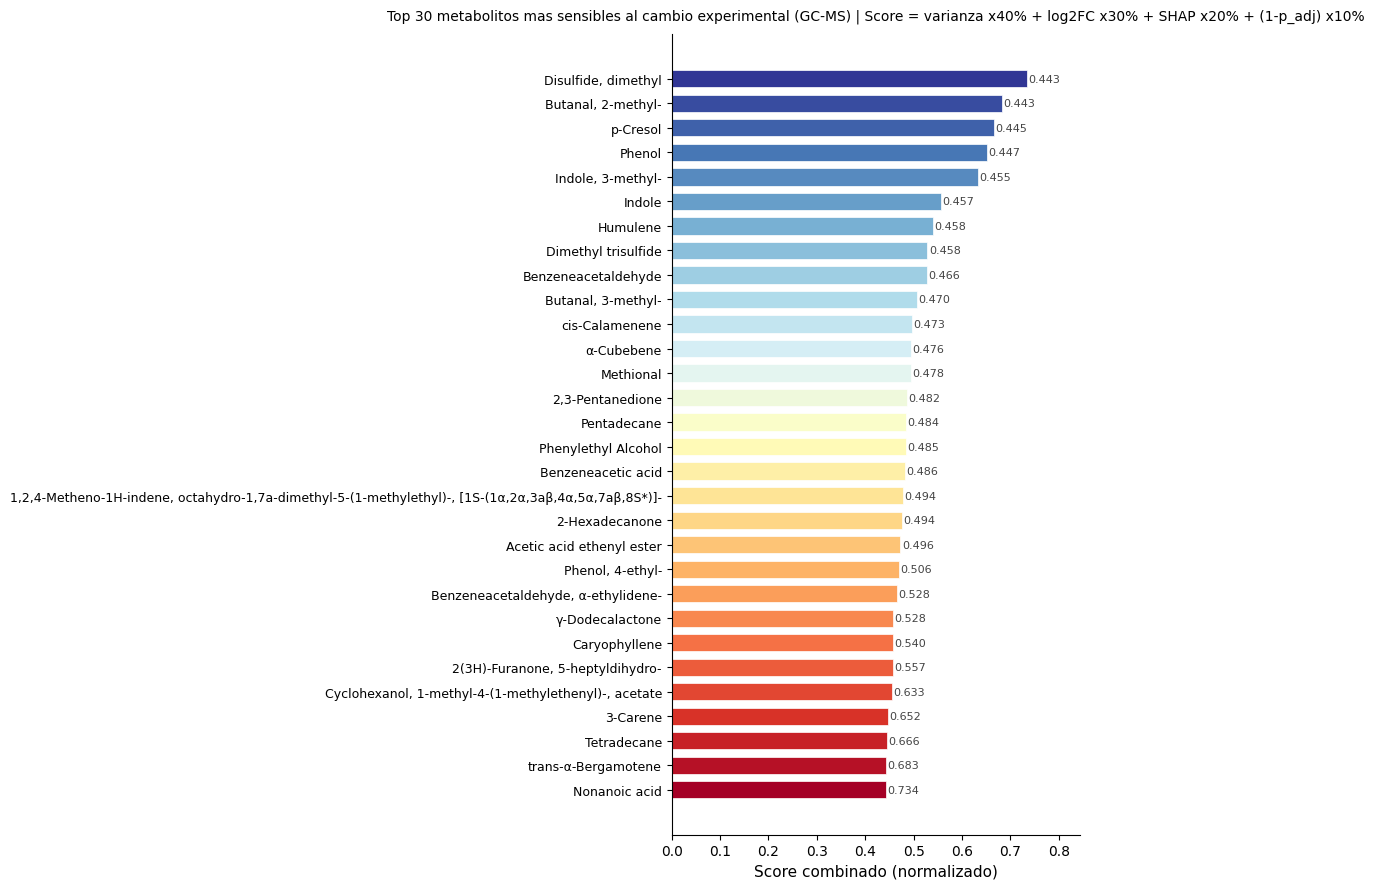

Grafica guardada: ..\data\processed csv\top_metabolites_barplot.png


In [24]:
TOP_PLOT = 30
fig, ax = plt.subplots(figsize=(11, 9))
top_plot = df_ranked.head(TOP_PLOT).copy()
names  = top_plot[met_col].astype(str).tolist()
scores = top_plot["final_score"].tolist()
cmap   = plt.cm.get_cmap("RdYlBu_r", len(names))
colors = [cmap(i) for i in range(len(names))]
bars = ax.barh(y=range(len(names)-1, -1, -1), width=scores,
               color=colors, edgecolor="white", linewidth=0.5, height=0.7)
for bar, score in zip(bars, reversed(scores)):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2,
            f"{score:.3f}", va="center", ha="left", fontsize=8, color="#444")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(list(reversed(names)), fontsize=9)
ax.set_xlabel("Score combinado (normalizado)", fontsize=11)
titulo = (
    f"Top {TOP_PLOT} metabolitos mas sensibles al cambio experimental (GC-MS)"
    f" | Score = varianza x{WEIGHTS['variance']:.0%} + log2FC x{WEIGHTS['log2fc']:.0%}"
    f" + SHAP x{WEIGHTS['shap']:.0%} + (1-p_adj) x{WEIGHTS['p_adjusted']:.0%}"
)
ax.set_title(titulo, fontsize=10, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, max(scores) * 1.15)
plt.tight_layout()
plt.savefig(DATA_OUT / "top_metabolites_barplot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafica guardada:", DATA_OUT / "top_metabolites_barplot.png")


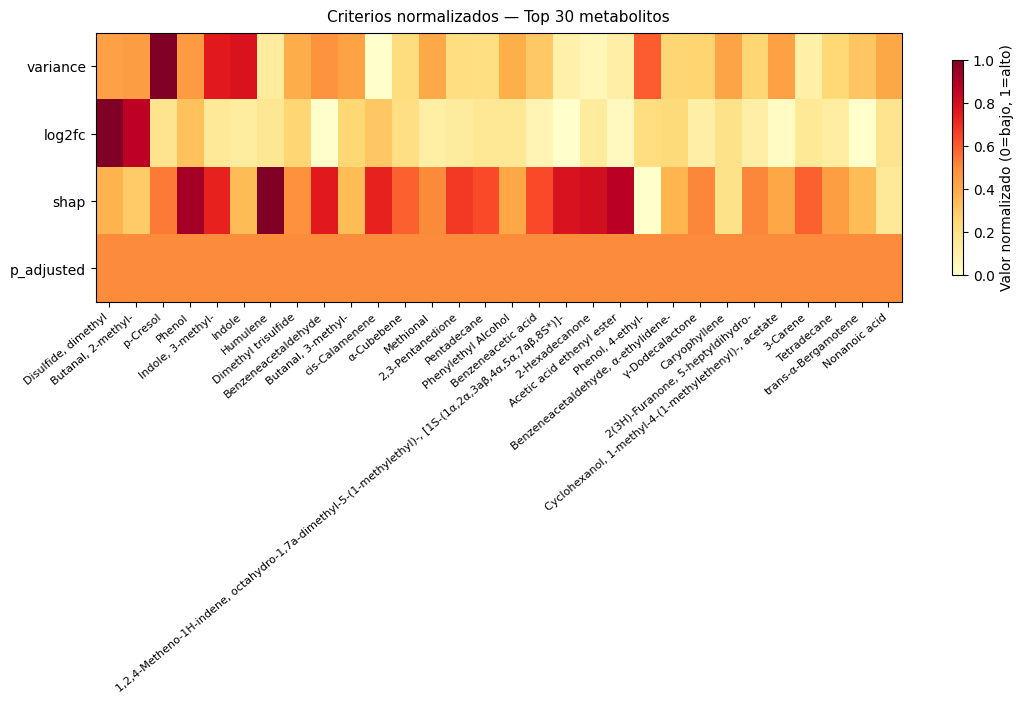

Heatmap guardado.


In [25]:
# HEATMAP: criterios individuales — Top 30
active_score_cols = {k: v for k, v in score_cols.items() if v is not None and v in df_ranked.columns}
if len(active_score_cols) >= 2:
    top_hm = df_ranked.head(TOP_PLOT).copy()
    heat_data = {}
    for key, col in active_score_cols.items():
        norm_vals = minmax_normalize(top_hm[col], invert=(key == 'p_adjusted')).fillna(0).values
        heat_data[key] = norm_vals
    heat_df = pd.DataFrame(heat_data, index=top_hm[met_col].values).T
    fig, ax = plt.subplots(figsize=(13, 3.5))
    im = ax.imshow(heat_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(heat_df.columns)))
    ax.set_xticklabels(heat_df.columns, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=10)
    ax.set_title(f'Criterios normalizados — Top {TOP_PLOT} metabolitos', fontsize=11, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Valor normalizado (0=bajo, 1=alto)')
    plt.tight_layout()
    plt.savefig(DATA_OUT / 'top_metabolites_criteria_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Heatmap guardado.')
else:
    print('Menos de 2 criterios activos — heatmap omitido.')


## 12. Tabla de duplicados descartados

In [26]:
# ============================================================
# REVISAR DUPLICADOS DESCARTADOS
# ============================================================

if not df_discarded.empty:
    print(f'Total de entradas descartadas: {len(df_discarded)}')
    print()

    # Resumen: cuántos duplicados tenía cada compuesto
    dup_summary = (
        df_discarded.groupby('_representative')
        .size()
        .reset_index(name='n_duplicates_removed')
        .sort_values('n_duplicates_removed', ascending=False)
    )

    print('Compuestos con más entradas redundantes eliminadas (top 15):')
    display(dup_summary.head(15))
else:
    print('No se encontraron duplicados en la tabla integrada (todos los metabolitos eran únicos).')

Total de entradas descartadas: 912

Compuestos con más entradas redundantes eliminadas (top 15):


,_representative,n_duplicates_removed
24,"Butanal, 2-methyl-",168
25,"Butanal, 3-methyl-",99
5,"2,3-Pentanedione",99
30,"Disulfide, dimethyl",48
22,"Benzeneacetaldehyde, α-ethylidene-",48
35,Methional,35
26,"Cyclohexanol, 1-methyl-4-(1-methylethenyl)-, acetate",35
21,Benzeneacetaldehyde,24
34,Hexanal,24
13,2-Pentanone,24


## 13. Exportar resultados

In [27]:
# ============================================================
# GUARDAR ARCHIVOS DE SALIDA PRINCIPALES
# ============================================================

out_master    = DATA_OUT / 'master_table_curated.csv'
out_ranked    = DATA_OUT / 'top_metabolites_ranked.csv'
out_discarded = DATA_OUT / 'discarded_duplicates.csv'

# 1) Tabla maestra depurada (todos los metabolitos únicos)
df_curated.to_csv(out_master, index=False, encoding='utf-8-sig')
print(f'master_table_curated.csv  -> {len(df_curated)} metabolitos')

# 2) Ranking completo filtrado (sin derivados irrelevantes)
df_ranked.to_csv(out_ranked, index=False, encoding='utf-8-sig')
print(f'top_metabolites_ranked.csv -> {len(df_ranked)} metabolitos')

# 3) Duplicados descartados
if not df_discarded.empty:
    df_discarded.to_csv(out_discarded, index=False, encoding='utf-8-sig')
    print(f'discarded_duplicates.csv  -> {len(df_discarded)} entradas')
else:
    print('discarded_duplicates.csv  -> vacio')

print('Exportacion completada.')


master_table_curated.csv  -> 143 metabolitos
top_metabolites_ranked.csv -> 138 metabolitos
discarded_duplicates.csv  -> 912 entradas
Exportacion completada.


## 14. Resumen final

In [28]:
# ============================================================
# RESUMEN DEL ANÁLISIS
# ============================================================

active_score_cols = {k: v for k, v in score_cols.items() if v is not None and v in df_curated.columns}

print('=' * 70)
print('RESUMEN — RANKING DE METABOLITOS (GC-MS)')
print('=' * 70)
print()
print(f'  Filas en tabla integrada original : {len(df_main)}')
print(f'  Metabolitos únicos (depurados)    : {len(df_curated)}')
print(f'  Entradas descartadas              : {len(df_discarded) if not df_discarded.empty else 0}')
print()
print('  Criterios usados en el score:')
total_w = sum(WEIGHTS[k] for k in active_score_cols)
for k, col in active_score_cols.items():
    w_adj = WEIGHTS.get(k, 0) / total_w
    print(f'    {k:15s} ({col:40s})  peso={w_adj:.3f}')
print()
print(f'  Criterios OMITIDOS (no disponibles):')
for k, col in score_cols.items():
    if col is None or col not in df_curated.columns:
        print(f'    {k:15s} — no disponible')
print()
print(f'  Top 8 metabolitos finales:')
for _, row in df_curated.head(8).iterrows():
    name  = row[met_col]
    score = row['final_score']
    rank  = int(row['rank'])
    print(f'    {rank}. {name[:50]:50s}  score={score:.4f}')
print()
print('Archivos guardados:')
print(f'  → {out_master}')
print(f'  → {out_ranked}')
print(f'  → {out_discarded}')

RESUMEN — RANKING DE METABOLITOS (GC-MS)

  Filas en tabla integrada original : 1055
  Metabolitos únicos (depurados)    : 143
  Entradas descartadas              : 912

  Criterios usados en el score:
    variance        (variance_between_conditions_log         )  peso=0.400
    log2fc          (abs_log2fc                              )  peso=0.300
    shap            (shap_mean_abs                           )  peso=0.200
    p_adjusted      (p_adjusted                              )  peso=0.100

  Criterios OMITIDOS (no disponibles):

  Top 8 metabolitos finales:
    1. Disulfide, dimethyl                                 score=0.7338
    2. Butanal, 2-methyl-                                  score=0.6829
    3. p-Cresol                                            score=0.6658
    4. Phenol                                              score=0.6518
    5. Indole, 3-methyl-                                   score=0.6334
    6. Indole                                              score=0.5